# MLP PyTorch — Experimentos e Comparação Final

**Objetivo:** treinar MLP com PyTorch, superar baselines, encontrar threshold ótimo por custo de negócio e comparar todos os modelos.

Arquitetura base: `[128, 64, 32]` + BatchNorm + ReLU + Dropout + early stopping

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pickle
import mlflow
import mlflow.pytorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, roc_curve, precision_recall_curve

from src import SEED
from src.data.loader import load_splits
from src.data.preprocessing import build_preprocessor, prepare_xy
from src.models.mlp import ChurnMLP, train, evaluate
from src.evaluation.metrics import compute_metrics, optimal_threshold, business_cost

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE} | PyTorch: {torch.__version__} | SEED: {SEED}')

Device: cpu | PyTorch: 2.12.0+cpu | SEED: 42


## 1. Dados e Pré-processamento

In [2]:
train_df, val_df, test_df = load_splits(base_dir='../data/raw')

with open('../models/preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

X_train, y_train = prepare_xy(train_df)
X_val,   y_val   = prepare_xy(val_df)
X_test,  y_test  = prepare_xy(test_df)

X_train_proc = preprocessor.transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

INPUT_DIM = X_train_proc.shape[1]
print(f'Input dim: {INPUT_DIM} | Train: {X_train_proc.shape[0]} | Val: {X_val_proc.shape[0]} | Test: {X_test_proc.shape[0]}')

Input dim: 45 | Train: 5633 | Val: 705 | Test: 705


In [8]:
def to_tensors(X, y):
    return (
        torch.tensor(X, dtype=torch.float32).to(DEVICE),
        torch.tensor(y.values, dtype=torch.float32).to(DEVICE),
    )

def make_loader(X, y, batch_size=64, shuffle=True, drop_last=False):
    Xt, yt = to_tensors(X, y)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)

# pos_weight para imbalance: n_neg / n_pos
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()], dtype=torch.float32).to(DEVICE)
print(f'pos_weight: {pos_weight.item():.2f}')

mlflow.set_tracking_uri('sqlite:///../mlflow.db')
mlflow.set_experiment('churn-mlp')

pos_weight: 2.77


<Experiment: artifact_location='file:c:/Users/Pedro/Desktop/Pós-Graduação/TechChallange/PósTech/notebooks/mlruns/2', creation_time=1781662701559, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1781662701559, lifecycle_stage='active', name='churn-mlp', tags={}, trace_location=None, workspace='default'>

## 2. Função de Treino + Avaliação

In [10]:
def run_experiment(hidden_dims, dropout, lr, batch_size=64, epochs=100, patience=10,
                   run_name=None, save_path='../models/best_mlp.pt'):
    train_loader = make_loader(X_train_proc, y_train, batch_size=batch_size, drop_last=True)
    val_loader   = make_loader(X_val_proc,   y_val,   batch_size=batch_size, shuffle=False)

    model = ChurnMLP(INPUT_DIM, hidden_dims, dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    epochs_trained = train(
        model, optimizer, criterion,
        train_loader, val_loader,
        epochs=epochs, patience=patience, save_path=save_path
    )

    # Carregar melhor checkpoint
    model.load_state_dict(torch.load(save_path, map_location=DEVICE, weights_only=True))
    model.eval()

    # Predições no test set
    X_test_t = torch.tensor(X_test_proc, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        logits = model(X_test_t)
        y_prob = torch.sigmoid(logits).cpu().numpy()

    threshold = optimal_threshold(y_test, y_prob)
    metrics = compute_metrics(y_test, y_prob, threshold=threshold)

    params = {
        'hidden_dims': str(hidden_dims),
        'dropout': dropout,
        'lr': lr,
        'batch_size': batch_size,
        'epochs_trained': epochs_trained,
        'patience': patience,
    }

    if run_name:
        with mlflow.start_run(run_name=run_name):
            mlflow.log_params(params)
            mlflow.log_metrics({
                'test_roc_auc': metrics['roc_auc'],
                'test_pr_auc':  metrics['pr_auc'],
                'test_f1':      metrics['f1'],
                'test_business_cost': metrics['business_cost'],
                'optimal_threshold': threshold,
            })
            mlflow.pytorch.log_model(model, artifact_path='model')

    return model, y_prob, metrics, params, epochs_trained

## 3. Experimento Base

In [11]:
print('Treinando MLP base: [128, 64, 32] | dropout=0.3 | lr=1e-3')

model_base, y_prob_base, metrics_base, params_base, ep_base = run_experiment(
    hidden_dims=[128, 64, 32],
    dropout=0.3,
    lr=1e-3,
    run_name='mlp_base_128_64_32',
)

print(f'\nEpocas treinadas: {ep_base}')
print(f'AUC-ROC:  {metrics_base["roc_auc"]:.4f}')
print(f'PR-AUC:   {metrics_base["pr_auc"]:.4f}')
print(f'F1:       {metrics_base["f1"]:.4f}')
print(f'Custo:    R${metrics_base["business_cost"]:,.0f}')
print(f'Threshold: {metrics_base["threshold"]:.2f}')

Treinando MLP base: [128, 64, 32] | dropout=0.3 | lr=1e-3


2026/06/16 23:23:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 23:23:27 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/16 23:23:44 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Epocas treinadas: 16
AUC-ROC:  0.8466
PR-AUC:   0.6556
F1:       0.5544
Custo:    R$17,250
Threshold: 0.21


## 4. Hyperparameter Tuning

In [12]:
hp_grid = [
    {'hidden_dims': [64, 32],       'dropout': 0.2, 'lr': 1e-3,  'name': 'mlp_64_32_d02_lr1e3'},
    {'hidden_dims': [128, 64, 32],  'dropout': 0.3, 'lr': 5e-4,  'name': 'mlp_128_64_32_d03_lr5e4'},
    {'hidden_dims': [128, 64, 32],  'dropout': 0.5, 'lr': 1e-3,  'name': 'mlp_128_64_32_d05_lr1e3'},
    {'hidden_dims': [256, 128, 64], 'dropout': 0.3, 'lr': 1e-3,  'name': 'mlp_256_128_64_d03_lr1e3'},
    {'hidden_dims': [256, 128, 64], 'dropout': 0.3, 'lr': 5e-4,  'name': 'mlp_256_128_64_d03_lr5e4'},
]

hp_results = []

for hp in hp_grid:
    print(f"\nExperimento: {hp['name']}")
    _, y_prob, metrics, params, ep = run_experiment(
        hidden_dims=hp['hidden_dims'],
        dropout=hp['dropout'],
        lr=hp['lr'],
        run_name=hp['name'],
        save_path=f"../models/mlp_{hp['name']}.pt",
    )
    hp_results.append({
        'name': hp['name'],
        'hidden_dims': str(hp['hidden_dims']),
        'dropout': hp['dropout'],
        'lr': hp['lr'],
        'epochs': ep,
        **metrics,
    })
    print(f'  AUC-ROC: {metrics["roc_auc"]:.4f} | F1: {metrics["f1"]:.4f} | Custo: R${metrics["business_cost"]:,.0f}')

print('\n✅ Todos os experimentos concluídos')


Experimento: mlp_64_32_d02_lr1e3


2026/06/16 23:24:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 23:24:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/16 23:24:59 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  AUC-ROC: 0.8470 | F1: 0.5591 | Custo: R$16,600

Experimento: mlp_128_64_32_d03_lr5e4


2026/06/16 23:25:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 23:25:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/16 23:25:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  AUC-ROC: 0.8484 | F1: 0.5609 | Custo: R$16,500

Experimento: mlp_128_64_32_d05_lr1e3


...

  AUC-ROC: 0.8463 | F1: 0.5571 | Custo: R$16,350

Experimento: mlp_256_128_64_d03_lr1e3


2026/06/16 23:26:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 23:26:08 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/16 23:26:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  AUC-ROC: 0.8486 | F1: 0.5714 | Custo: R$17,400

Experimento: mlp_256_128_64_d03_lr5e4


2026/06/16 23:26:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 23:26:33 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/16 23:26:43 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  AUC-ROC: 0.8505 | F1: 0.5557 | Custo: R$16,800

✅ Todos os experimentos concluídos


In [13]:
# Adicionar experimento base
hp_results.insert(0, {
    'name': 'mlp_base_128_64_32',
    'hidden_dims': '[128, 64, 32]',
    'dropout': 0.3,
    'lr': 1e-3,
    'epochs': ep_base,
    **metrics_base,
})

df_hp = pd.DataFrame(hp_results).sort_values('roc_auc', ascending=False)
print('=== RESULTADOS HYPERPARAMETER TUNING ===')
df_hp[['name', 'hidden_dims', 'dropout', 'lr', 'epochs',
       'roc_auc', 'pr_auc', 'f1', 'business_cost', 'threshold']]

=== RESULTADOS HYPERPARAMETER TUNING ===


,name,hidden_dims,dropout,lr,epochs,roc_auc,pr_auc,f1,business_cost,threshold
5,mlp_256_128_64_d03_lr5e4,"[256, 128, 64]",0.3,0.0005,14,0.850536,0.650786,0.555725,16800.0,0.19
4,mlp_256_128_64_d03_lr1e3,"[256, 128, 64]",0.3,0.0010,17,0.848626,0.653585,0.571429,17400.0,0.22
2,mlp_128_64_32_d03_lr5e4,"[128, 64, 32]",0.3,0.0005,17,0.848409,0.655410,0.560863,16500.0,0.24
1,mlp_64_32_d02_lr1e3,"[64, 32]",0.2,0.0010,12,0.846974,0.645356,0.559140,16600.0,0.22
0,mlp_base_128_64_32,"[128, 64, 32]",0.3,0.0010,16,0.846613,0.655596,0.554364,17250.0,0.21
3,mlp_128_64_32_d05_lr1e3,"[128, 64, 32]",0.5,0.0010,18,0.846293,0.650717,0.557078,16350.0,0.22


## 5. Selecionar Melhor Modelo + Salvar Artefatos

In [14]:
best_row = df_hp.iloc[0]
best_name = best_row['name']
print(f'Melhor modelo: {best_name}')
print(f'  AUC-ROC: {best_row["roc_auc"]:.4f}')
print(f'  PR-AUC:  {best_row["pr_auc"]:.4f}')
print(f'  F1:      {best_row["f1"]:.4f}')
print(f'  Custo:   R${best_row["business_cost"]:,.0f}')
print(f'  Thresh:  {best_row["threshold"]:.2f}')

# Retreinar o melhor com save em best_mlp.pt
import ast
best_hidden = ast.literal_eval(best_row['hidden_dims'])
best_model, y_prob_best, metrics_best, _, _ = run_experiment(
    hidden_dims=best_hidden,
    dropout=float(best_row['dropout']),
    lr=float(best_row['lr']),
    run_name=f'{best_name}_final',
    save_path='../models/best_mlp.pt',
)

# Salvar threshold ótimo
np.save('../models/threshold.npy', np.array(metrics_best['threshold']))
print(f'\nArtefatos salvos: models/best_mlp.pt | models/threshold.npy')

Melhor modelo: mlp_256_128_64_d03_lr5e4
  AUC-ROC: 0.8505
  PR-AUC:  0.6508
  F1:      0.5557
  Custo:   R$16,800
  Thresh:  0.19


2026/06/16 23:27:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 23:27:32 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/16 23:27:43 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Artefatos salvos: models/best_mlp.pt | models/threshold.npy


## 6. Análise de Custo × Threshold — Melhor MLP

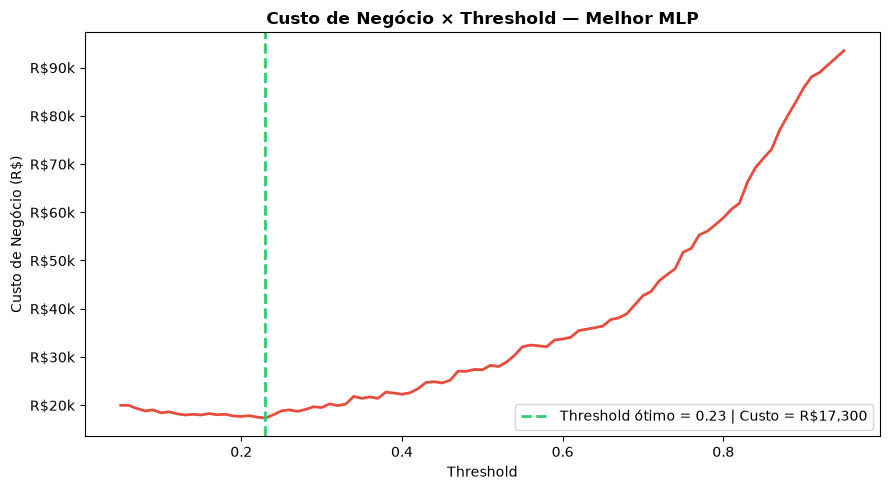

In [15]:
thresholds = np.linspace(0.05, 0.95, 91)
costs = [business_cost(y_test, (y_prob_best >= t).astype(int)) for t in thresholds]
opt_t = thresholds[np.argmin(costs)]
opt_c = min(costs)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, costs, color='#e74c3c', linewidth=2)
ax.axvline(opt_t, color='#2ecc71', linestyle='--', linewidth=2,
           label=f'Threshold ótimo = {opt_t:.2f} | Custo = R${opt_c:,.0f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Custo de Negócio (R$)')
ax.set_title('Custo de Negócio × Threshold — Melhor MLP', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'R${v/1000:.0f}k'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../docs/mlp_cost_threshold.png', bbox_inches='tight')
plt.show()

## 7. Curvas ROC + PR — MLP vs Melhor Baseline

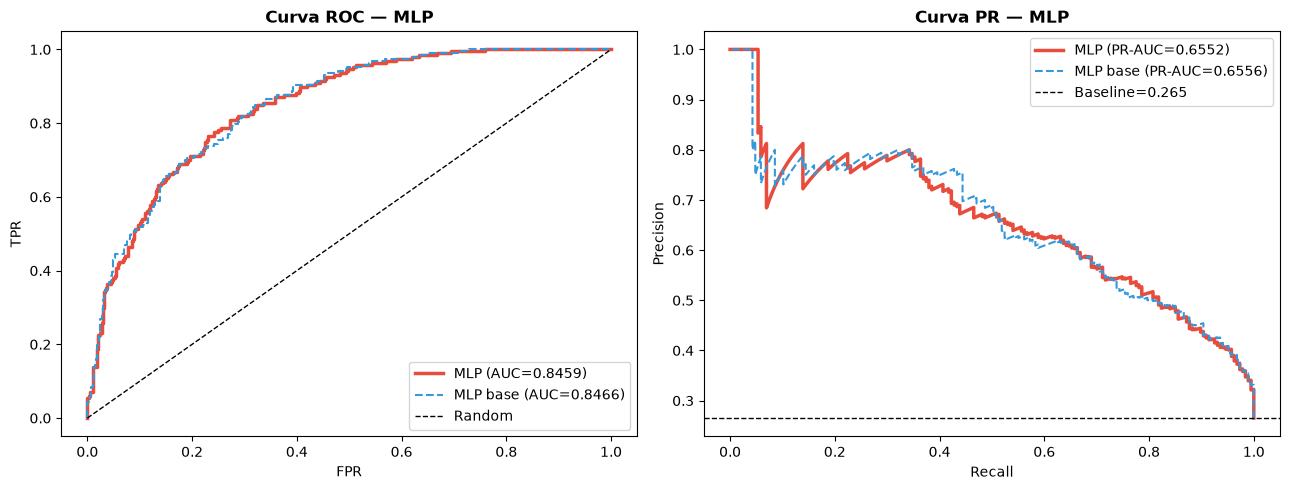

In [16]:
# Carregar melhor baseline salvo
import os
baseline_pkl = None
for f in ['../models/preprocessor.pkl']:
    if os.path.exists(f):
        baseline_pkl = f

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# MLP
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
axes[0].plot(fpr, tpr, color='#e74c3c', linewidth=2.5,
             label=f'MLP (AUC={metrics_best["roc_auc"]:.4f})')

prec, rec, _ = precision_recall_curve(y_test, y_prob_best)
axes[1].plot(rec, prec, color='#e74c3c', linewidth=2.5,
             label=f'MLP (PR-AUC={metrics_best["pr_auc"]:.4f})')

# MLP base
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_base)
axes[0].plot(fpr_b, tpr_b, color='#3498db', linewidth=1.5, linestyle='--',
             label=f'MLP base (AUC={metrics_base["roc_auc"]:.4f})')

prec_b, rec_b, _ = precision_recall_curve(y_test, y_prob_base)
axes[1].plot(rec_b, prec_b, color='#3498db', linewidth=1.5, linestyle='--',
             label=f'MLP base (PR-AUC={metrics_base["pr_auc"]:.4f})')

axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC — MLP', fontweight='bold')
axes[0].legend()

axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', linewidth=1,
                label=f'Baseline={y_test.mean():.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva PR — MLP', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/mlp_roc_pr_curves.png', bbox_inches='tight')
plt.show()

## 8. Tabela Comparativa Final — Todos os Modelos

In [17]:
# Carregar resultados dos baselines do MLflow
client = mlflow.tracking.MlflowClient('sqlite:///../mlflow.db')
exp = client.get_experiment_by_name('churn-baselines')

baseline_rows = []
if exp:
    runs = client.search_runs(
        experiment_ids=[exp.experiment_id],
        filter_string="",
        order_by=["metrics.test_roc_auc DESC"]
    )
    seen = set()
    for run in runs:
        name = run.data.params.get('model', run.info.run_name)
        if name in seen:
            continue
        seen.add(name)
        m = run.data.metrics
        baseline_rows.append({
            'Modelo': name,
            'Tipo': 'Baseline',
            'AUC-ROC': round(m.get('test_roc_auc', 0), 4),
            'PR-AUC':  round(m.get('test_pr_auc', 0), 4),
            'F1':      round(m.get('test_f1', 0), 4),
            'Custo':   f"R${m.get('test_business_cost', 0):,.0f}",
            'Threshold': round(m.get('test_threshold', 0.5), 2),
        })

mlp_row = {
    'Modelo': f'MLP PyTorch ({best_row["hidden_dims"]})',
    'Tipo': '★ MLP',
    'AUC-ROC': round(metrics_best['roc_auc'], 4),
    'PR-AUC':  round(metrics_best['pr_auc'], 4),
    'F1':      round(metrics_best['f1'], 4),
    'Custo':   f"R${metrics_best['business_cost']:,.0f}",
    'Threshold': round(metrics_best['threshold'], 2),
}

df_final = pd.DataFrame(baseline_rows + [mlp_row]).set_index('Modelo')
print('=== TABELA COMPARATIVA FINAL ===')
df_final

=== TABELA COMPARATIVA FINAL ===


,Tipo,AUC-ROC,PR-AUC,F1,Custo,Threshold
Modelo,,,,,,
logistic_regression,Baseline,0.8528,0.6575,0.5710,"R$18,550",0.10
gradient_boosting,Baseline,0.8510,0.6775,0.5876,"R$19,200",0.12
xgboost,Baseline,0.8294,0.6510,0.5891,"R$22,550",0.10
random_forest,Baseline,0.8203,0.6193,0.5625,"R$20,500",0.11
dummy,Baseline,0.5000,0.2652,0.0000,"R$93,500",0.50
"MLP PyTorch ([256, 128, 64])",★ MLP,0.8459,0.6552,0.5665,"R$17,300",0.23


## 9. Resumo Final

In [18]:
print('=== RESUMO FINAL ===')
print()
print(f'Melhor MLP:')
print(f'  Arquitetura:  {best_row["hidden_dims"]}')
print(f'  Dropout:      {best_row["dropout"]}')
print(f'  LR:           {best_row["lr"]}')
print(f'  AUC-ROC:      {metrics_best["roc_auc"]:.4f}')
print(f'  PR-AUC:       {metrics_best["pr_auc"]:.4f}')
print(f'  F1:           {metrics_best["f1"]:.4f}')
print(f'  Custo:        R${metrics_best["business_cost"]:,.0f}')
print(f'  Threshold:    {metrics_best["threshold"]:.2f}')
print()
print(f'Artefatos salvos:')
print(f'  models/best_mlp.pt')
print(f'  models/preprocessor.pkl')
print(f'  models/threshold.npy')
print()
print('→ API pode ser iniciada com: make run-api')
print('→ MLflow UI:                 .venv/Scripts/mlflow ui --backend-store-uri sqlite:///mlflow.db')

=== RESUMO FINAL ===

Melhor MLP:
  Arquitetura:  [256, 128, 64]
  Dropout:      0.3
  LR:           0.0005
  AUC-ROC:      0.8459
  PR-AUC:       0.6552
  F1:           0.5665
  Custo:        R$17,300
  Threshold:    0.23

Artefatos salvos:
  models/best_mlp.pt
  models/preprocessor.pkl
  models/threshold.npy

→ API pode ser iniciada com: make run-api
→ MLflow UI:                 .venv/Scripts/mlflow ui --backend-store-uri sqlite:///mlflow.db
